In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [35]:
df=pd.read_csv("1_airline_passenger_satisfaction.csv")

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      125000 non-null  int64  
 1   Gender                                  125000 non-null  object 
 2   Age                                     125000 non-null  int64  
 3   Customer Type                           125000 non-null  object 
 4   Type of Travel                          125000 non-null  object 
 5   Class                                   125000 non-null  object 
 6   Flight Distance                         125000 non-null  int64  
 7   Departure Delay                         125000 non-null  int64  
 8   Arrival Delay                           124624 non-null  float64
 9   Departure and Arrival Time Convenience  125000 non-null  int64  
 10  Ease of Online Booking                  1250

In [37]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [38]:
df.drop(columns=['ID'], inplace=True)

In [39]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [40]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

In [41]:
df['Customer Type'].unique()

array(['First-time', 'Returning'], dtype=object)

In [42]:
df['Customer Type'] = df['Customer Type'].map({
    'disloyal Customer': 0,
    'Loyal Customer': 1
})

In [43]:
df['Type of Travel'].unique()

array(['Business', 'Personal'], dtype=object)

In [44]:
df['Type of Travel'] = df['Type of Travel'].map({
    'Personal Travel': 0,
    'Business travel': 1
})

In [45]:
df['Class'].unique()

array(['Business', 'Economy', 'Economy Plus'], dtype=object)

In [46]:
df['Class'] = df['Class'].map({
    'Eco': 0,
    'Eco Plus': 1,
    'Business': 2
})

In [47]:
df['Satisfaction'].unique()

array(['Neutral or Dissatisfied', 'Satisfied'], dtype=object)

In [48]:
df['Satisfaction'] = df['Satisfaction'].map({
    'neutral or dissatisfied': 0,
    'satisfied': 1
})

In [49]:
print(df.dtypes)
print(df.head())

Gender                                      int64
Age                                         int64
Customer Type                             float64
Type of Travel                            float64
Class                                     float64
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                                int64
Leg Room Service                            int64
Cleanliness                                 int64
Food and Drink                              int64
In-flight Service                           int64
In-flight Wifi Service                      int64


In [50]:
correlation_matrix = df.corr(method='pearson')

In [51]:
print(correlation_matrix)

                                          Gender       Age  Customer Type  \
Gender                                  1.000000  0.008000            NaN   
Age                                     0.008000  1.000000            NaN   
Customer Type                                NaN       NaN            NaN   
Type of Travel                               NaN       NaN            NaN   
Class                                        NaN       NaN            NaN   
Flight Distance                         0.003565  0.099177            NaN   
Departure Delay                         0.003868 -0.009213            NaN   
Arrival Delay                           0.001848 -0.011172            NaN   
Departure and Arrival Time Convenience  0.008193  0.035946            NaN   
Ease of Online Booking                  0.005396  0.021872            NaN   
Check-in Service                        0.007334  0.032377            NaN   
Online Boarding                        -0.046785  0.206328            NaN   

In [52]:
correlation_matrix.to_csv('korelacijska_matrica.csv')

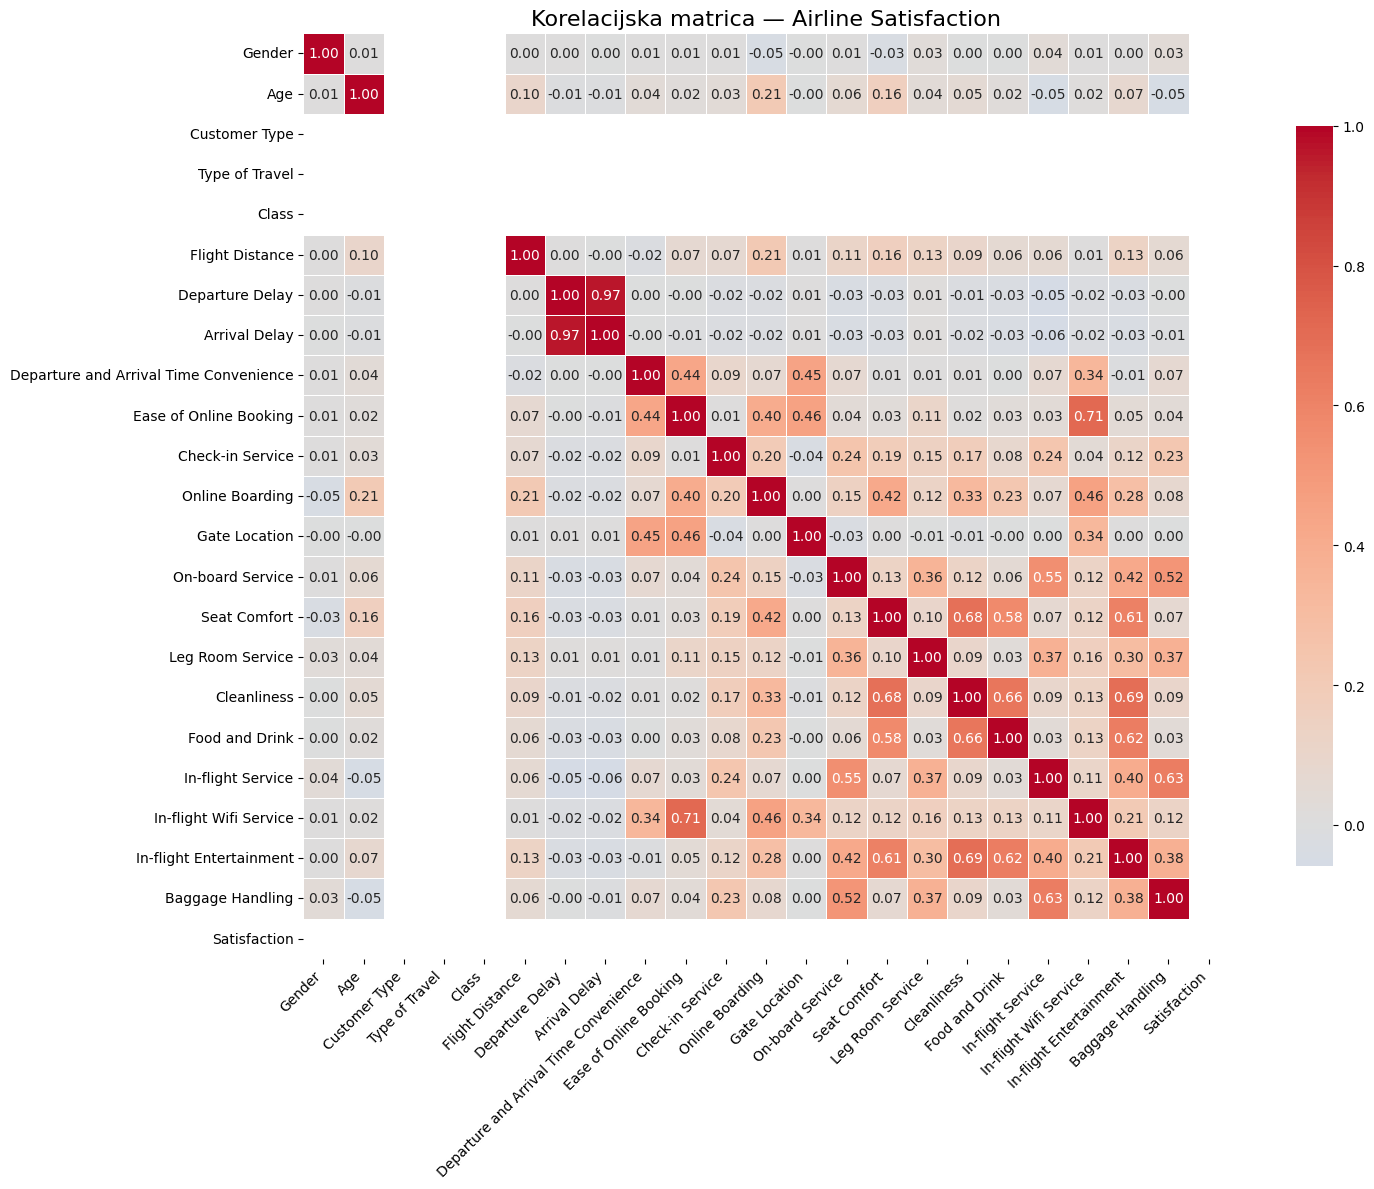

In [53]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,          # prikaži brojeve
    fmt='.2f',           # 2 decimale
    cmap='coolwarm',     # boja: plava (negativna) → crvena (pozitivna)
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Korelacijska matrica — Airline Satisfaction', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('korelacijska_matrica.png', dpi=150)
plt.show()